## Construcción de una Red Neuronal con Propósito

### Estudiantes:
* Nathalia Chaves Oviedo C22195
* Brayan Rivera Navarro C26477
* Gael Alpízar Alfaro C20270

## Instrucciones:
Para el laboratorio, se va a construir una red neuronal con ayuda de alguna inteligencia artificial, en python con el tipo de red perceptrón multicapa.

En el perceptrón multicapa la información fluye en una sola dirección: de la capa de entrada a la de salida.


# Perceptrón Multicapa para Heart Failure Prediction

In [ ]:
# Imports de libreria

import kagglehub
import pandas as pd
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Dataset

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

df = pd.read_csv(os.path.join(path, "heart.csv"))

df.head()

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


La variable `HeartDisease` es binaria:

*   0 = No presenta enfermedad cardíaca
*   1 = Presenta enfermedad cardíaca

Por lo tanto, este es un problema de clasificación binaria.

In [ ]:
df.info()
df.describe()
print("Etiquetas de salida:", df["HeartDisease"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Etiquetas de salida: [0 1]


### Variables de entrada y salida; categóricas a numéricas

*   `X`: contiene las variables de entrada del modelo, como edad, sexo, colesterol, presión arterial, entre otras.
*   `y`: contiene la variable que queremos predecir.

Las redes neuronales trabajan con números.
Por eso, columnas como `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina` y `ST_Slope` se convierten a valores numéricos usando `pd.get_dummies().`

In [ ]:
# Separar variables de entrada y salida
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


### Dividir datos en entrenamiento, prueba y escalamiento de datos

Separamos los datos en:

* 80% entrenamiento
* 20% prueba

El modelo aprende con los datos de entrenamiento y luego se evalúa con datos que no ha visto.

El escalamiento es importante porque las variables tienen rangos diferentes.
Por ejemplo, la edad puede estar entre 30 y 80, mientras que el colesterol puede tener valores mayores a 200.

Las redes neuronales funcionan mejor cuando los datos están en escalas similares.

In [ ]:
# Separar datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Escalamiento
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Crear el Perceptrón Multicapa

La arquitectura implementada corresponde a un Perceptrón Multicapa (MLP), ya que posee múltiples capas densamente conectadas: una capa de entrada, dos capas ocultas y una capa de salida.

Las capas ocultas utilizan la función de activación ReLU para introducir no linealidad en el modelo, mientras que la capa de salida utiliza Sigmoid para producir probabilidades en un problema de clasificación binaria.

* La función `relu` se usa en las capas ocultas porque ayuda al modelo a aprender patrones no lineales.

* La función `sigmoid` se usa en la salida porque el problema es de clasificación binaria.

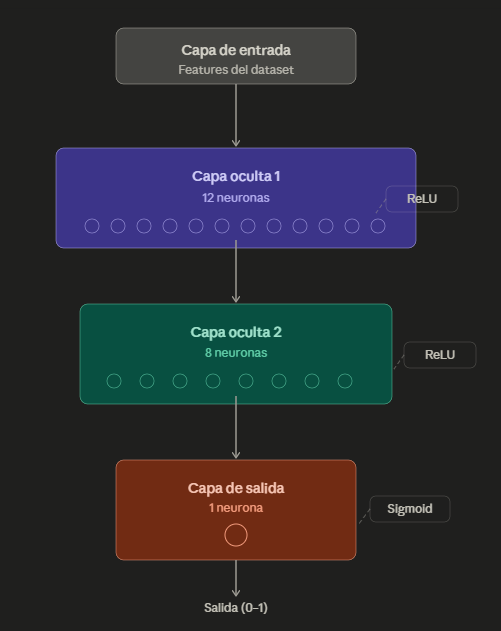

In [ ]:
model = Sequential()

# Primera capa oculta
model.add(Dense(12, input_shape=(X_train.shape[1],), activation='relu'))

# Segunda capa oculta
model.add(Dense(8, activation='relu'))

# Capa de salida
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compilar el modelo

Como la salida es binaria, se usa:
```
loss='binary_crossentropy'
```
El optimizador adam ajusta los pesos de la red durante el entrenamiento.

La métrica accuracy indica qué porcentaje de predicciones fueron correctas.

In [ ]:
# Compilación del modelo

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

### Entrenar y evaluar el modelo

El modelo se entrena durante 150 épocas.

`batch_size=10` significa que el modelo actualiza sus pesos cada 10 registros.

`validation_split=0.2` separa una parte de los datos de entrenamiento para validación.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=10,
    validation_split=0.2
)

Epoch 1/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6286 - loss: 0.6298 - val_accuracy: 0.7551 - val_loss: 0.5621
Epoch 2/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8211 - loss: 0.5277 - val_accuracy: 0.8231 - val_loss: 0.4875
Epoch 3/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8535 - loss: 0.4526 - val_accuracy: 0.8503 - val_loss: 0.4384
Epoch 4/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8671 - loss: 0.3962 - val_accuracy: 0.8571 - val_loss: 0.4067
Epoch 5/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8671 - loss: 0.3586 - val_accuracy: 0.8571 - val_loss: 0.3946
Epoch 6/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8739 - loss: 0.3363 - val_accuracy: 0.8571 - val_loss: 0.3902
Epoch 7/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8739 - loss: 0.3218 - val_accuracy: 0.8503 - val_loss: 0.3868
Epoch 8/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8790 - loss: 0.3128 - val_accuracy: 0.8503 - v

Se evalúa el modelo con datos de prueba.

El `accuracy` indica qué tan bien predice el modelo en datos nuevos.

In [ ]:
# Realizar predicciones

loss, accuracy = model.evaluate(X_test, y_test)

print("Pérdida:", loss)
print("Accuracy: %.2f" % (accuracy * 100))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8533 - loss: 0.4086 
Pérdida: 0.4086041748523712
Accuracy: 85.33


### Predicciones del Modelo

En esta etapa se realizan las predicciones del modelo utilizando los datos de prueba.

La red neuronal devuelve probabilidades entre 0 y 1. Estas probabilidades representan qué tan probable es que un paciente presente enfermedad cardíaca.

Por ejemplo:

* 0.87 → Alta probabilidad de enfermedad cardíaca.
* 0.12 → Baja probabilidad de enfermedad cardíaca.

Posteriormente, las probabilidades se convierten en clases binarias utilizando un umbral de 0.5:

* Si la probabilidad es mayor a 0.5 → clase 1.
* Si la probabilidad es menor o igual a 0.5 → clase 0.

De esta forma, el modelo transforma sus resultados en una predicción final para cada paciente.

In [ ]:
# Realizar predicciones con los datos de prueba

predictions = model.predict(X_test)

# Mostrar las primeras probabilidades generadas por el modelo

print("Primeras probabilidades:")
print(predictions[:10])

# Convertir probabilidades en clases binarias

y_pred = (predictions > 0.5).astype(int)

# Mostrar las primeras clases predichas

print("\nPrimeras clases predichas:")
print(y_pred[:10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Primeras probabilidades:
[[0.00372825]
 [0.03653648]
 [0.99983317]
 [0.9433645 ]
 [0.06828177]
 [0.31942642]
 [0.9915508 ]
 [0.01243388]
 [0.81100905]
 [0.99526024]]

Primeras clases predichas:
[[0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]]
